# Segundo modelo — predicción de ronda de draft

En este notebook exploro mejoras sobre el modelo base (`xgb_draft_balanceado.pkl`) con tres estrategias:

1. **RandomizedSearchCV** sobre XGBoost para encontrar mejores hiperparámetros
2. **LightGBM** como modelo alternativo con pesos balanceados
3. **Selección de variables** usando feature importance para quedarnos con las más relevantes

El objetivo es mejorar el macro avg F1, especialmente en R1 y R2 que son las clases que más nos interesan.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.preprocessing import label_binarize
from xgboost import XGBClassifier
import lightgbm as lgb


## Cargo los datos y preparo X e y

Mismo preprocesado que en el primer modelo.

In [17]:
ncaa = pd.read_csv('../../datos/procesados/ncaa_final.csv')

# separo variables y target
X = ncaa.drop(columns=['ronda', 'rango_pick'])
y = ncaa['ronda']

# one hot encoding de posicion
X = pd.get_dummies(X, columns=['posicion'], drop_first=False)

# encodifico el target
le_target_draft = LabelEncoder()
y_enc = le_target_draft.fit_transform(y)  # ND=0, R1=1, R2=2

print("Clases:", le_target_draft.classes_)
print("Distribución:", pd.Series(y_enc).value_counts(normalize=True).round(3).to_dict())


Clases: ['ND' 'R1' 'R2']
Distribución: {0: 0.707, 1: 0.152, 2: 0.141}


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc,
    test_size=0.15,
    random_state=11,
    stratify=y_enc
)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")


Train: (1802, 43) | Test: (319, 43)


## Selección de variables — antes de entrenar

Antes de lanzar el RandomizedSearch, identificamos qué variables aportan información real. Entrenamos un XGBoost rápido con todos los features, extraemos importancias y probamos distintos umbrales mediante validación cruzada ligera (3 folds).

El subconjunto ganador reemplaza `X_train` y `X_test` para el resto del notebook: todos los modelos trabajan ya con los features filtrados desde el principio.

Features totales: 43

Top 20 por importancia:
pts                          0.0642
gbpm                         0.0591
bpm                          0.0516
usg                          0.0456
stops                        0.0373
mp                           0.0329
altura_cm                    0.0317
stl                          0.0282
GP                           0.0282
blk                          0.0279
TS_per                       0.0279
stl_per                      0.0251
ogbpm                        0.0249
TO_per                       0.0244
midmade/(midmade+midmiss)    0.0244
ast/tov                      0.0240
posicion_Wing G              0.0233
blk_per                      0.0227
posicion_PF/C                0.0218
treb                         0.0214


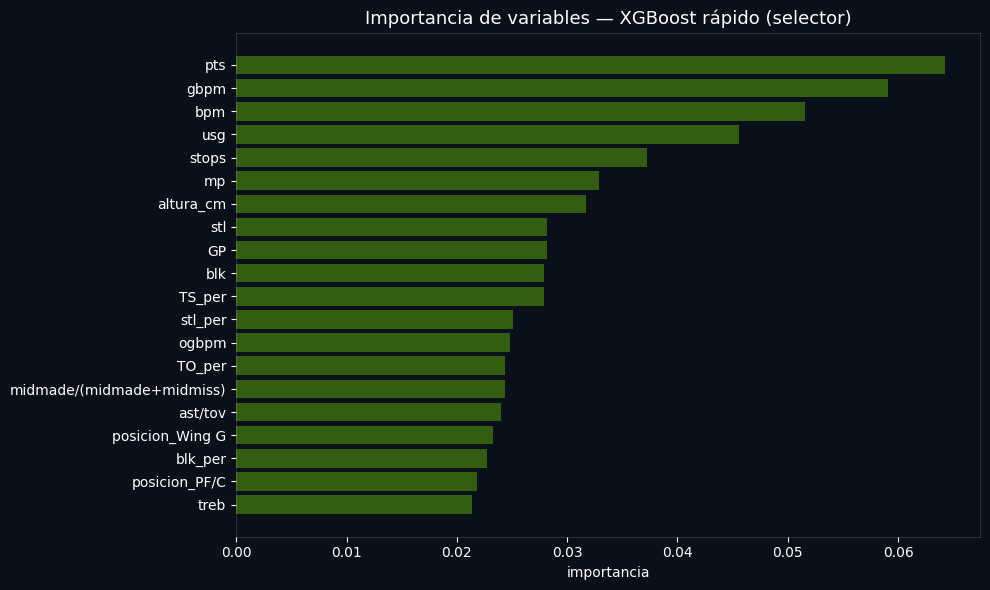

In [19]:
# ── paso 1: XGBoost rápido sobre todos los features ──────────────────────────
xgb_selector = XGBClassifier(
    objective='multi:softmax',
    num_class=3,
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=11,
    eval_metric='mlogloss'
)
pesos_selector = compute_sample_weight(class_weight='balanced', y=y_train)
xgb_selector.fit(X_train, y_train, sample_weight=pesos_selector)

importancias_sel = pd.Series(
    xgb_selector.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(f"Features totales: {len(importancias_sel)}")
print("\nTop 20 por importancia:")
print(importancias_sel.head(20).round(4).to_string())

# visualización de importancias
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#0a1019')
ax.set_facecolor('#0a1019')
top20 = importancias_sel.head(20)
ax.barh(top20.index[::-1], top20.values[::-1], color='#3B6D11', alpha=0.85)
ax.set_xlabel('importancia', color='white')
ax.set_title('Importancia de variables — XGBoost rápido (selector)', color='white', fontsize=13)
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_edgecolor('#ffffff22')
plt.tight_layout()
plt.show()

In [20]:
# ── paso 2: candidatos por umbral acumulado y por número fijo ────────────────
importancia_norm = importancias_sel / importancias_sel.sum()
importancia_acum = importancia_norm.cumsum()

candidatos = {}

# umbral acumulado: variables que explican el X% de la importancia total
for umbral in [0.80, 0.90, 0.95]:
    vars_umbral = importancia_acum[importancia_acum <= umbral].index.tolist()
    # si quedan 0 (primera var ya supera el umbral), cogemos al menos 1
    if not vars_umbral:
        vars_umbral = [importancias_sel.index[0]]
    candidatos[f'acum_{int(umbral*100)}pct'] = vars_umbral

# número fijo
for n in [10, 15, 20]:
    candidatos[f'top{n}'] = importancias_sel.head(n).index.tolist()

print("Candidatos generados:")
for nombre, vars_ in candidatos.items():
    print(f"  {nombre}: {len(vars_)} variables")

Candidatos generados:
  acum_80pct: 27 variables
  acum_90pct: 33 variables
  acum_95pct: 36 variables
  top10: 10 variables
  top15: 15 variables
  top20: 20 variables


In [21]:
# ── paso 3: CV rápida (3 folds) para cada candidato ─────────────────────────
# nota: no pasamos sample_weight aquí — cross_val_score no lo admite directamente
# en versiones recientes de sklearn. para selección de features no hace falta:
# el desbalanceo afecta igual a todos los candidatos, la comparación sigue siendo válida.
cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=11)

xgb_cv = XGBClassifier(
    objective='multi:softmax',
    num_class=3,
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=11,
    eval_metric='mlogloss'
)

resultados_sel = {}
for nombre, vars_ in candidatos.items():
    scores = cross_val_score(
        xgb_cv,
        X_train[vars_], y_train,
        scoring='f1_macro',
        cv=cv3,
        n_jobs=-1
    )
    resultados_sel[nombre] = {'vars': vars_, 'f1_mean': scores.mean(), 'f1_std': scores.std()}
    print(f"  {nombre:15s} ({len(vars_):2d} vars) → F1 macro: {scores.mean():.4f} ± {scores.std():.4f}")

# también evalúo todas las variables como referencia
scores_all = cross_val_score(
    xgb_cv, X_train, y_train,
    scoring='f1_macro', cv=cv3, n_jobs=-1
)
print(f"  {'todas':15s} ({X_train.shape[1]:2d} vars) → F1 macro: {scores_all.mean():.4f} ± {scores_all.std():.4f} (referencia)")

  acum_80pct      (27 vars) → F1 macro: 0.5407 ± 0.0186
  acum_90pct      (33 vars) → F1 macro: 0.5443 ± 0.0224
  acum_95pct      (36 vars) → F1 macro: 0.5513 ± 0.0268
  top10           (10 vars) → F1 macro: 0.5355 ± 0.0166
  top15           (15 vars) → F1 macro: 0.5467 ± 0.0283
  top20           (20 vars) → F1 macro: 0.5395 ± 0.0192
  todas           (43 vars) → F1 macro: 0.5499 ± 0.0299 (referencia)


In [22]:
# ── paso 4: elijo el mejor candidato y redefino X_train / X_test ─────────────
mejor_candidato = max(resultados_sel, key=lambda k: resultados_sel[k]['f1_mean'])
vars_seleccionadas = resultados_sel[mejor_candidato]['vars']

print(f"Candidato elegido: {mejor_candidato}")
print(f"Variables seleccionadas ({len(vars_seleccionadas)}): {vars_seleccionadas}")
print(f"F1 macro CV: {resultados_sel[mejor_candidato]['f1_mean']:.4f}")

# redefino X_train y X_test — el resto del notebook hereda este subconjunto
X_train = X_train[vars_seleccionadas]
X_test  = X_test[vars_seleccionadas]

print(f"\nX_train redefinido: {X_train.shape}")
print(f"X_test  redefinido: {X_test.shape}")

Candidato elegido: acum_95pct
Variables seleccionadas (36): ['pts', 'gbpm', 'bpm', 'usg', 'stops', 'mp', 'altura_cm', 'stl', 'GP', 'blk', 'TS_per', 'stl_per', 'ogbpm', 'TO_per', 'midmade/(midmade+midmiss)', 'ast/tov', 'posicion_Wing G', 'blk_per', 'posicion_PF/C', 'treb', 'ftr', 'Min_per', 'AST_per', 'rimmade/(rimmade+rimmiss)', 'TP_per', 'DRB_per', 'drtg', 'ast', 'obpm', 'eFG', 'Ortg', 'dgbpm', 'ORB_per', 'dbpm', 'posicion_Pure PG', 'twoP_per']
F1 macro CV: 0.5513

X_train redefinido: (1802, 36)
X_test  redefinido: (319, 36)


## Estrategia 1 — RandomizedSearchCV sobre XGBoost

El modelo base usaba parámetros fijos (`n_estimators=100`, `max_depth=4`, `learning_rate=0.1`). Aquí exploramos un espacio más amplio usando búsqueda aleatoria con validación cruzada estratificada para no perder el equilibrio de clases en cada fold.

In [23]:
# calculo pesos balanceados para el entrenamiento
pesos_train = compute_sample_weight(class_weight='balanced', y=y_train)

# espacio de hiperparámetros a explorar
param_dist = {
    'n_estimators':   [100, 200, 300, 400],
    'max_depth':      [3, 4, 5, 6],
    'learning_rate':  [0.01, 0.05, 0.1, 0.2],
    'subsample':      [0.6, 0.7, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma':          [0, 0.1, 0.3, 0.5]
}

# modelo base sobre el que se busca
xgb_base = XGBClassifier(
    objective='multi:softmax',
    num_class=3,
    random_state=11,
    eval_metric='mlogloss'
)

# validación cruzada estratificada — 5 folds
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=11)

# búsqueda aleatoria: 50 combinaciones, puntuando por macro F1
rnd_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=50,          # número de combinaciones a probar
    scoring='f1_macro', # optimizo macro F1 (penaliza por igual R1, R2 y ND)
    cv=cv,
    random_state=11,
    n_jobs=-1,          # uso todos los cores disponibles
    verbose=1
)

# entreno con pesos para que el modelo vea R1 y R2 amplificadas
rnd_search.fit(X_train, y_train, sample_weight=pesos_train)

print("\nMejores hiperparámetros encontrados:")
for k, v in rnd_search.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nMejor F1 macro en CV: {rnd_search.best_score_:.4f}")


Fitting 5 folds for each of 50 candidates, totalling 250 fits

Mejores hiperparámetros encontrados:
  subsample: 1.0
  n_estimators: 200
  min_child_weight: 1
  max_depth: 3
  learning_rate: 0.01
  gamma: 0.5
  colsample_bytree: 1.0

Mejor F1 macro en CV: 0.5585


In [24]:
# evalúo el mejor modelo en el test
mejor_xgb = rnd_search.best_estimator_

y_pred_rxgb = mejor_xgb.predict(X_test)

print("=== Mejor XGBoost (RandomizedSearch) ===")
print(classification_report(y_test, y_pred_rxgb, target_names=le_target_draft.classes_))


=== Mejor XGBoost (RandomizedSearch) ===
              precision    recall  f1-score   support

          ND       0.96      0.77      0.86       226
          R1       0.41      0.58      0.48        48
          R2       0.43      0.67      0.53        45

    accuracy                           0.73       319
   macro avg       0.60      0.67      0.62       319
weighted avg       0.80      0.73      0.75       319



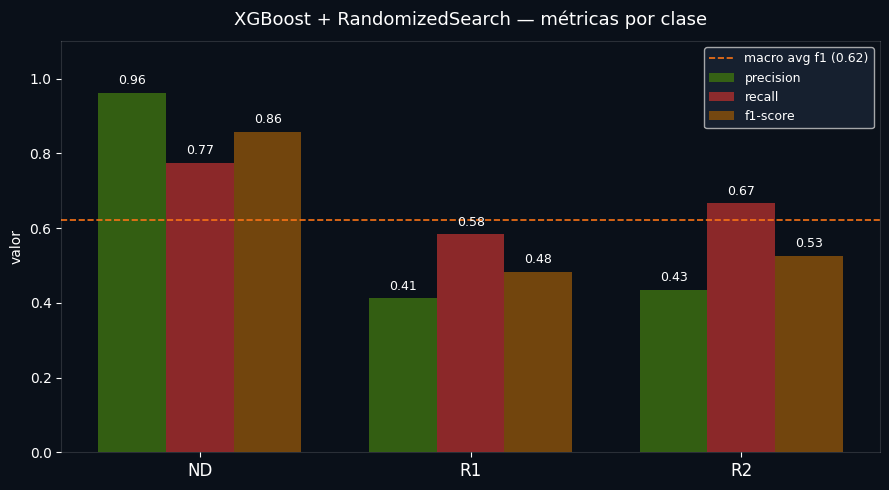

In [25]:
# visualización del classification report
clases = le_target_draft.classes_.tolist()
report = classification_report(y_test, y_pred_rxgb, target_names=clases, output_dict=True)

precision = [report[c]['precision'] for c in clases]
recall    = [report[c]['recall']    for c in clases]
f1        = [report[c]['f1-score']  for c in clases]

metricas = {'precision': precision, 'recall': recall, 'f1-score': f1}
colores  = ['#3B6D11', '#A32D2D', '#854F0B']

x = np.arange(len(clases))
ancho = 0.25

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor('#0a1019')
ax.set_facecolor('#0a1019')

for i, (nombre, valores) in enumerate(metricas.items()):
    barras = ax.bar(x + i * ancho, valores, ancho, label=nombre, color=colores[i], alpha=0.85)
    for barra in barras:
        alto = barra.get_height()
        ax.text(barra.get_x() + barra.get_width() / 2, alto + 0.015,
                f'{alto:.2f}', ha='center', va='bottom', fontsize=9, color='white')

macro_f1 = report['macro avg']['f1-score']
ax.axhline(y=macro_f1, color='#f97316', linestyle='--', linewidth=1.2,
           label=f'macro avg f1 ({macro_f1:.2f})')

ax.set_xticks(x + ancho)
ax.set_xticklabels(clases, color='white', fontsize=12)
ax.set_ylim(0, 1.1)
ax.set_ylabel('valor', color='white')
ax.set_title('XGBoost + RandomizedSearch — métricas por clase', color='white', fontsize=13, pad=12)
ax.tick_params(colors='white')
ax.legend(facecolor='#1a2535', labelcolor='white', fontsize=9)
for spine in ax.spines.values():
    spine.set_edgecolor('#ffffff22')

plt.tight_layout()
plt.show()


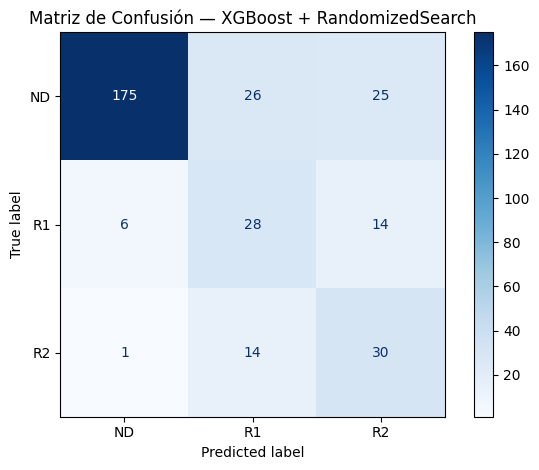

In [26]:
# matriz de confusión
cm_rxgb = confusion_matrix(y_test, y_pred_rxgb)
disp = ConfusionMatrixDisplay(cm_rxgb, display_labels=le_target_draft.classes_)
disp.plot(cmap='Blues')
plt.title('Matriz de Confusión — XGBoost + RandomizedSearch')
plt.tight_layout()
plt.show()


## Estrategia 1b — GridSearch afinado sobre los mejores parámetros

El RandomizedSearch nos da el mejor punto en un espacio amplio. Ahora construimos una rejilla estrecha alrededor de esos valores para exprimir las últimas décimas de F1.

La idea: si RandomizedSearch encontró `max_depth=4` y `learning_rate=0.05`, exploramos `max_depth=[3,4,5]` y `learning_rate=[0.03, 0.05, 0.07]`. Pocos valores, mucho foco.

In [27]:
# recupero los mejores parámetros del RandomizedSearch
best = rnd_search.best_params_
print("Punto de partida (mejores parámetros del RandomizedSearch):")
for k, v in best.items():
    print(f"  {k}: {v}")

# construyo rejilla estrecha alrededor de cada valor
def vecinos(val, opciones):
    """devuelve hasta 3 valores: el encontrado y sus vecinos en la lista de opciones"""
    if val not in opciones:
        opciones = sorted(opciones + [val])
    idx = opciones.index(val)
    return sorted(set(opciones[max(0, idx-1): idx+2]))

param_grid = {
    'n_estimators':     vecinos(best['n_estimators'],   [100, 200, 300, 400]),
    'max_depth':        vecinos(best['max_depth'],       [3, 4, 5, 6]),
    'learning_rate':    vecinos(best['learning_rate'],   [0.01, 0.05, 0.1, 0.2]),
    'subsample':        [best['subsample']],
    'colsample_bytree': [best['colsample_bytree']],
    'min_child_weight': vecinos(best['min_child_weight'],[1, 3, 5]),
    'gamma':            vecinos(best['gamma'],           [0, 0.1, 0.3, 0.5]),
}

n_combinaciones = 1
for v in param_grid.values():
    n_combinaciones *= len(v)
print(f"\nCombinaciones a evaluar: {n_combinaciones}")

from sklearn.model_selection import GridSearchCV

xgb_grid_base = XGBClassifier(
    objective='multi:softmax',
    num_class=3,
    random_state=11,
    eval_metric='mlogloss'
)

grid_search = GridSearchCV(
    estimator=xgb_grid_base,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=11),
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train, sample_weight=pesos_train)

print("\nMejores hiperparámetros (GridSearch):")
for k, v in grid_search.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nMejor F1 macro en CV (GridSearch):     {grid_search.best_score_:.4f}")
print(f"Mejor F1 macro en CV (RandomizedSearch): {rnd_search.best_score_:.4f}")
print(f"Mejora:                                  {grid_search.best_score_ - rnd_search.best_score_:+.4f}")

Punto de partida (mejores parámetros del RandomizedSearch):
  subsample: 1.0
  n_estimators: 200
  min_child_weight: 1
  max_depth: 3
  learning_rate: 0.01
  gamma: 0.5
  colsample_bytree: 1.0

Combinaciones a evaluar: 48
Fitting 5 folds for each of 48 candidates, totalling 240 fits

Mejores hiperparámetros (GridSearch):
  colsample_bytree: 1.0
  gamma: 0.3
  learning_rate: 0.01
  max_depth: 3
  min_child_weight: 3
  n_estimators: 200
  subsample: 1.0

Mejor F1 macro en CV (GridSearch):     0.5590
Mejor F1 macro en CV (RandomizedSearch): 0.5585
Mejora:                                  +0.0005


In [28]:
# evalúo el modelo afinado en test
xgb_grid = grid_search.best_estimator_
y_pred_grid = xgb_grid.predict(X_test)

print("=== XGBoost GridSearch afinado ===")
print(classification_report(y_test, y_pred_grid, target_names=le_target_draft.classes_))

=== XGBoost GridSearch afinado ===
              precision    recall  f1-score   support

          ND       0.96      0.78      0.86       226
          R1       0.40      0.58      0.47        48
          R2       0.44      0.64      0.52        45

    accuracy                           0.73       319
   macro avg       0.60      0.67      0.62       319
weighted avg       0.80      0.73      0.75       319



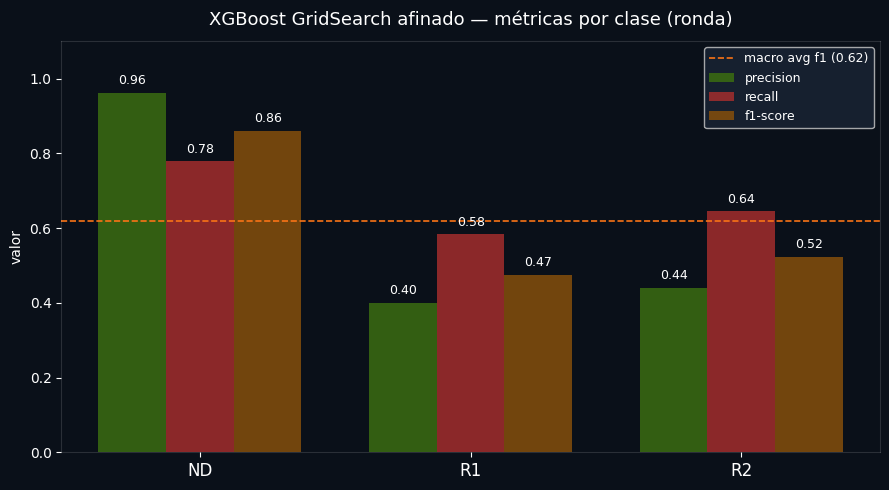

In [29]:
# visualización GridSearch
report_grid = classification_report(y_test, y_pred_grid, target_names=clases, output_dict=True)

precision_g = [report_grid[c]['precision'] for c in clases]
recall_g    = [report_grid[c]['recall']    for c in clases]
f1_g        = [report_grid[c]['f1-score']  for c in clases]
metricas_g  = {'precision': precision_g, 'recall': recall_g, 'f1-score': f1_g}

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor('#0a1019')
ax.set_facecolor('#0a1019')
for i, (nombre, valores) in enumerate(metricas_g.items()):
    barras = ax.bar(x + i * ancho, valores, ancho, label=nombre, color=colores[i], alpha=0.85)
    for barra in barras:
        alto = barra.get_height()
        ax.text(barra.get_x() + barra.get_width() / 2, alto + 0.015,
                f'{alto:.2f}', ha='center', va='bottom', fontsize=9, color='white')

macro_f1_g = report_grid['macro avg']['f1-score']
ax.axhline(y=macro_f1_g, color='#f97316', linestyle='--', linewidth=1.2,
           label=f'macro avg f1 ({macro_f1_g:.2f})')
ax.set_xticks(x + ancho)
ax.set_xticklabels(clases, color='white', fontsize=12)
ax.set_ylim(0, 1.1)
ax.set_ylabel('valor', color='white')
ax.set_title('XGBoost GridSearch afinado — métricas por clase (ronda)', color='white', fontsize=13, pad=12)
ax.tick_params(colors='white')
ax.legend(facecolor='#1a2535', labelcolor='white', fontsize=9)
for spine in ax.spines.values():
    spine.set_edgecolor('#ffffff22')
plt.tight_layout()
plt.show()

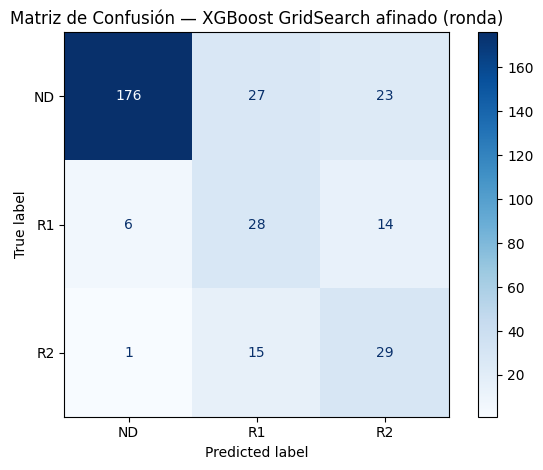

In [30]:
cm_grid = confusion_matrix(y_test, y_pred_grid)
disp_grid = ConfusionMatrixDisplay(cm_grid, display_labels=le_target_draft.classes_)
disp_grid.plot(cmap='Blues')
plt.title('Matriz de Confusión — XGBoost GridSearch afinado (ronda)')
plt.tight_layout()
plt.show()

## Estrategia 2 — LightGBM con pesos balanceados

LightGBM es un boosting alternativo a XGBoost. Su ventaja principal es la velocidad (usa histogramas en vez de ordenar todos los datos en cada split), pero también suele generalizar mejor en datasets pequeños. Aquí uso `class_weight='balanced'` directamente en el modelo, que es más limpio que `compute_sample_weight`.

In [31]:
lgbm_model = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=3,
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=10,  # mínimo de muestras en una hoja — regulariza el modelo
    class_weight='balanced',
    random_state=11,
    verbose=-1             # silencio los logs de entrenamiento
)

lgbm_model.fit(X_train, y_train)

y_pred_lgbm = lgbm_model.predict(X_test)

print("=== LightGBM balanceado ===")
print(classification_report(y_test, y_pred_lgbm, target_names=le_target_draft.classes_))


=== LightGBM balanceado ===
              precision    recall  f1-score   support

          ND       0.89      0.88      0.88       226
          R1       0.40      0.35      0.37        48
          R2       0.38      0.44      0.41        45

    accuracy                           0.74       319
   macro avg       0.55      0.56      0.55       319
weighted avg       0.74      0.74      0.74       319



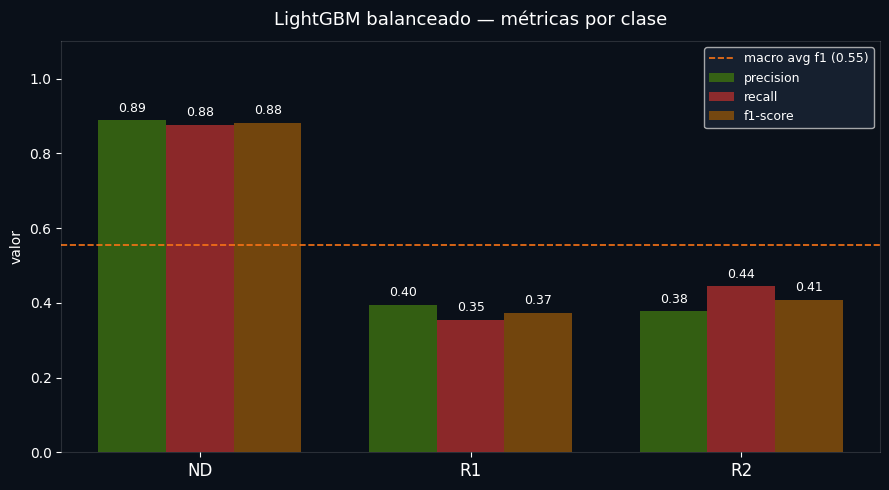

In [32]:
# visualización LightGBM
report_lgbm = classification_report(y_test, y_pred_lgbm, target_names=clases, output_dict=True)

precision_l = [report_lgbm[c]['precision'] for c in clases]
recall_l    = [report_lgbm[c]['recall']    for c in clases]
f1_l        = [report_lgbm[c]['f1-score']  for c in clases]

metricas_l = {'precision': precision_l, 'recall': recall_l, 'f1-score': f1_l}

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor('#0a1019')
ax.set_facecolor('#0a1019')

for i, (nombre, valores) in enumerate(metricas_l.items()):
    barras = ax.bar(x + i * ancho, valores, ancho, label=nombre, color=colores[i], alpha=0.85)
    for barra in barras:
        alto = barra.get_height()
        ax.text(barra.get_x() + barra.get_width() / 2, alto + 0.015,
                f'{alto:.2f}', ha='center', va='bottom', fontsize=9, color='white')

macro_f1_l = report_lgbm['macro avg']['f1-score']
ax.axhline(y=macro_f1_l, color='#f97316', linestyle='--', linewidth=1.2,
           label=f'macro avg f1 ({macro_f1_l:.2f})')

ax.set_xticks(x + ancho)
ax.set_xticklabels(clases, color='white', fontsize=12)
ax.set_ylim(0, 1.1)
ax.set_ylabel('valor', color='white')
ax.set_title('LightGBM balanceado — métricas por clase', color='white', fontsize=13, pad=12)
ax.tick_params(colors='white')
ax.legend(facecolor='#1a2535', labelcolor='white', fontsize=9)
for spine in ax.spines.values():
    spine.set_edgecolor('#ffffff22')
plt.tight_layout()
plt.show()


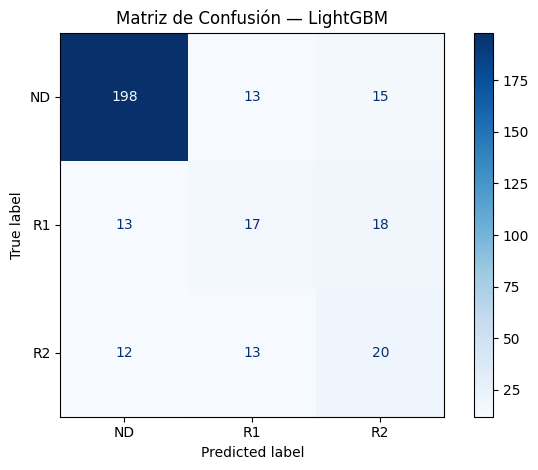

In [33]:
cm_lgbm = confusion_matrix(y_test, y_pred_lgbm)
disp_lgbm = ConfusionMatrixDisplay(cm_lgbm, display_labels=le_target_draft.classes_)
disp_lgbm.plot(cmap='Blues')
plt.title('Matriz de Confusión — LightGBM')
plt.tight_layout()
plt.show()


## Estrategia 3 — Feature importance + selección de variables

Uno de los problemas del modelo base es que tiene ~35 variables, muchas correlacionadas entre sí. Usando la importancia de variables del XGBoost optimizado, nos quedamos solo con las top N y vemos si el modelo mantiene o mejora el rendimiento con menos ruido.

> **Nota:** aquí la importancia se calcula sobre el XGBoost optimizado (RandomizedSearch + GridSearch) para ver si el ranking cambia respecto al selector inicial.

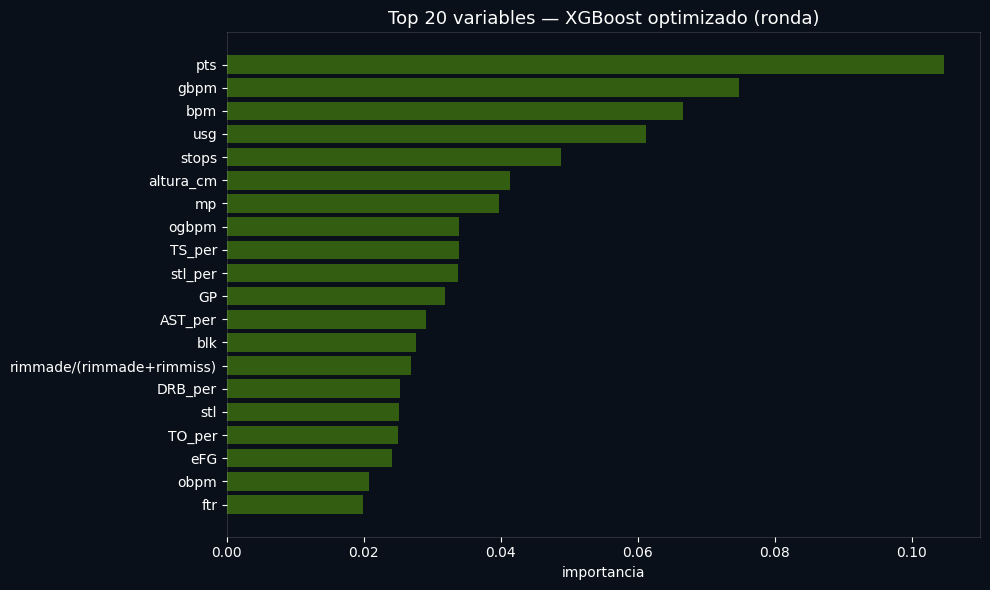

In [34]:
# importancia de variables del mejor XGBoost
importancias = pd.Series(
    mejor_xgb.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

# visualización
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#0a1019')
ax.set_facecolor('#0a1019')
top20 = importancias.head(20)
ax.barh(top20.index[::-1], top20.values[::-1], color='#3B6D11', alpha=0.85)
ax.set_xlabel('importancia', color='white')
ax.set_title('Top 20 variables — XGBoost optimizado (ronda)', color='white', fontsize=13)
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_edgecolor('#ffffff22')
plt.tight_layout()
plt.show()


In [35]:
# me quedo con las top 15 variables más importantes
top15_vars = importancias.head(15).index.tolist()
print("Variables seleccionadas:")
for v in top15_vars:
    print(f"  - {v}")

X_train_top = X_train[top15_vars]
X_test_top  = X_test[top15_vars]


Variables seleccionadas:
  - pts
  - gbpm
  - bpm
  - usg
  - stops
  - altura_cm
  - mp
  - ogbpm
  - TS_per
  - stl_per
  - GP
  - AST_per
  - blk
  - rimmade/(rimmade+rimmiss)
  - DRB_per


In [36]:
# entreno el LightGBM con solo las top 15 variables
lgbm_top = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=3,
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=10,
    class_weight='balanced',
    random_state=11,
    verbose=-1
)

lgbm_top.fit(X_train_top, y_train)
y_pred_top = lgbm_top.predict(X_test_top)

print("=== LightGBM con top 15 variables ===")
print(classification_report(y_test, y_pred_top, target_names=le_target_draft.classes_))


=== LightGBM con top 15 variables ===
              precision    recall  f1-score   support

          ND       0.91      0.87      0.89       226
          R1       0.40      0.42      0.41        48
          R2       0.37      0.42      0.39        45

    accuracy                           0.74       319
   macro avg       0.56      0.57      0.56       319
weighted avg       0.75      0.74      0.75       319



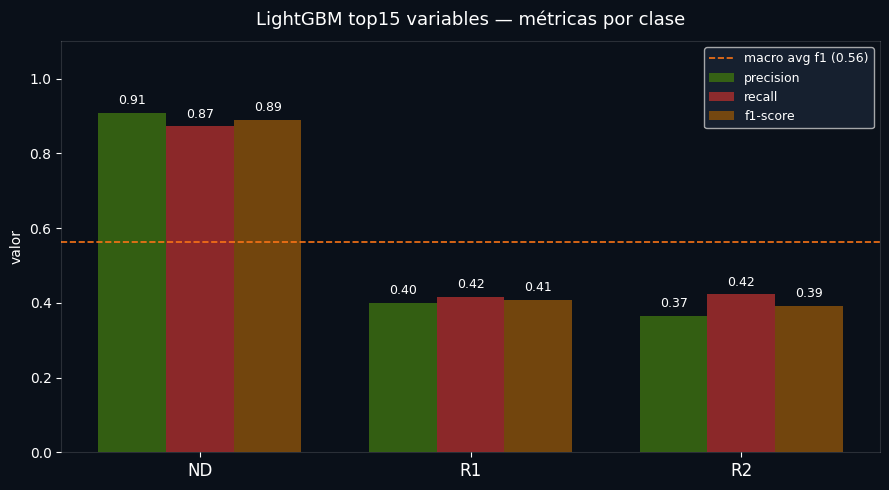

In [37]:
# visualización LightGBM top15
report_top = classification_report(y_test, y_pred_top, target_names=clases, output_dict=True)

precision_t = [report_top[c]['precision'] for c in clases]
recall_t    = [report_top[c]['recall']    for c in clases]
f1_t        = [report_top[c]['f1-score']  for c in clases]

metricas_t = {'precision': precision_t, 'recall': recall_t, 'f1-score': f1_t}

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor('#0a1019')
ax.set_facecolor('#0a1019')

for i, (nombre, valores) in enumerate(metricas_t.items()):
    barras = ax.bar(x + i * ancho, valores, ancho, label=nombre, color=colores[i], alpha=0.85)
    for barra in barras:
        alto = barra.get_height()
        ax.text(barra.get_x() + barra.get_width() / 2, alto + 0.015,
                f'{alto:.2f}', ha='center', va='bottom', fontsize=9, color='white')

macro_f1_t = report_top['macro avg']['f1-score']
ax.axhline(y=macro_f1_t, color='#f97316', linestyle='--', linewidth=1.2,
           label=f'macro avg f1 ({macro_f1_t:.2f})')

ax.set_xticks(x + ancho)
ax.set_xticklabels(clases, color='white', fontsize=12)
ax.set_ylim(0, 1.1)
ax.set_ylabel('valor', color='white')
ax.set_title('LightGBM top15 variables — métricas por clase', color='white', fontsize=13, pad=12)
ax.tick_params(colors='white')
ax.legend(facecolor='#1a2535', labelcolor='white', fontsize=9)
for spine in ax.spines.values():
    spine.set_edgecolor('#ffffff22')
plt.tight_layout()
plt.show()

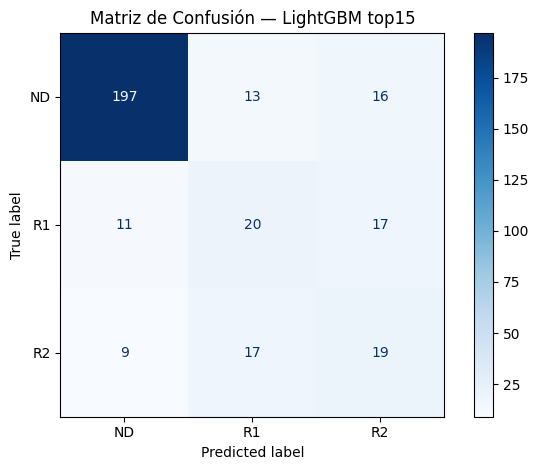

In [38]:
cm_top = confusion_matrix(y_test, y_pred_top)
disp_top = ConfusionMatrixDisplay(cm_top, display_labels=le_target_draft.classes_)
disp_top.plot(cmap='Blues')
plt.title('Matriz de Confusión — LightGBM top15')
plt.tight_layout()
plt.show()

## Estrategia 4 — Random Forest con pesos balanceados

Random Forest es un ensemble de árboles de decisión independientes (bagging), a diferencia de XGBoost y LightGBM que construyen árboles en secuencia (boosting). Aquí `class_weight='balanced'` ajusta automáticamente el peso de cada clase inversamente proporcional a su frecuencia.

In [39]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=11,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("=== Random Forest balanceado ===")
print(classification_report(y_test, y_pred_rf, target_names=le_target_draft.classes_))


=== Random Forest balanceado ===
              precision    recall  f1-score   support

          ND       0.91      0.88      0.89       226
          R1       0.51      0.58      0.54        48
          R2       0.45      0.47      0.46        45

    accuracy                           0.77       319
   macro avg       0.62      0.64      0.63       319
weighted avg       0.79      0.77      0.78       319



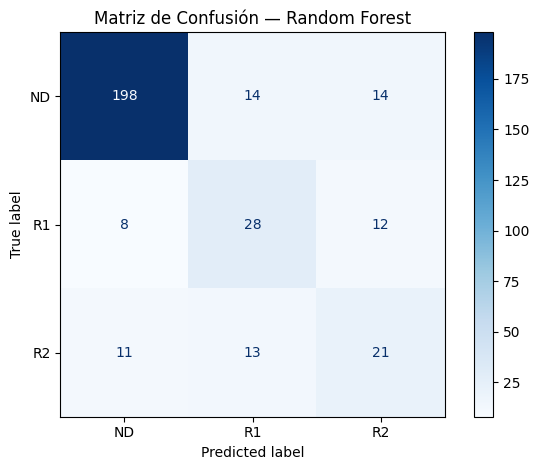

In [40]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(cm_rf, display_labels=le_target_draft.classes_)
disp_rf.plot(cmap='Blues')
plt.title('Matriz de Confusión — Random Forest')
plt.tight_layout()
plt.show()


## Estrategia 5 — SVM con kernel RBF

SVM (Support Vector Machine) con kernel RBF busca el hiperplano de máximo margen en un espacio de alta dimensión. Es el modelo más diferente conceptualmente a los anteriores: en vez de construir árboles, separa clases mediante fronteras de decisión no lineales. Requiere escalar las variables porque es sensible a la magnitud.

In [41]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# pipeline: escala + SVM — el escalado es obligatorio para SVM
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(
        kernel='rbf',
        C=1.0,           # penalización por error de clasificación
        gamma='scale',   # gamma = 1 / (n_features * X.var())
        class_weight='balanced',
        probability=True, # necesario para predict_proba y AUC-ROC
        random_state=11
    ))
])

svm_pipeline.fit(X_train, y_train)
y_pred_svm = svm_pipeline.predict(X_test)

print("=== SVM kernel RBF ===")
print(classification_report(y_test, y_pred_svm, target_names=le_target_draft.classes_))


=== SVM kernel RBF ===
              precision    recall  f1-score   support

          ND       0.96      0.76      0.85       226
          R1       0.38      0.48      0.43        48
          R2       0.33      0.58      0.42        45

    accuracy                           0.69       319
   macro avg       0.56      0.61      0.56       319
weighted avg       0.78      0.69      0.72       319



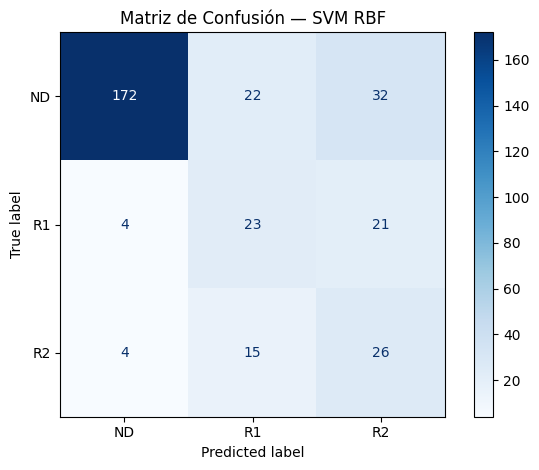

In [42]:
cm_svm = confusion_matrix(y_test, y_pred_svm)
disp_svm = ConfusionMatrixDisplay(cm_svm, display_labels=le_target_draft.classes_)
disp_svm.plot(cmap='Blues')
plt.title('Matriz de Confusión — SVM RBF')
plt.tight_layout()
plt.show()


## Estrategia 6 — Regresión Logística

Modelo lineal que estima probabilidades de clase mediante la función sigmoide (o softmax en multiclase). Es el modelo más interpretable de todos — sus coeficientes indican directamente la influencia de cada variable. Sirve como baseline lineal para comparar contra los modelos no lineales.

In [45]:
from sklearn.linear_model import LogisticRegression

# también requiere escalado — las regularizaciones L1/L2 son sensibles a la magnitud
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(
        solver='lbfgs',      # multinomial es el comportamiento por defecto en sklearn >= 1.5
        max_iter=1000,
        class_weight='balanced',
        random_state=11
    ))
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

print("=== Regresión Logística ===")
print(classification_report(y_test, y_pred_lr, target_names=le_target_draft.classes_))

=== Regresión Logística ===
              precision    recall  f1-score   support

          ND       0.93      0.69      0.79       226
          R1       0.35      0.58      0.44        48
          R2       0.30      0.49      0.37        45

    accuracy                           0.64       319
   macro avg       0.53      0.59      0.53       319
weighted avg       0.75      0.64      0.68       319



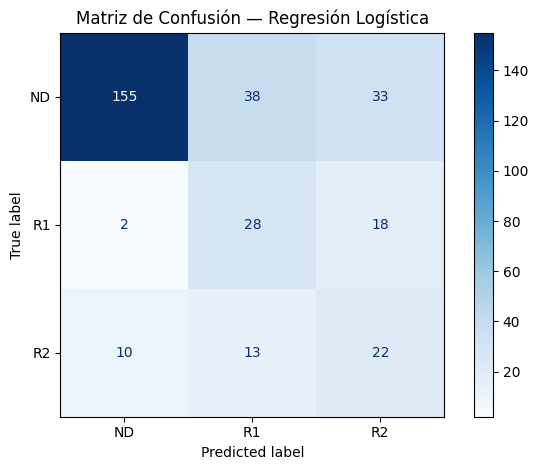

In [46]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp_lr = ConfusionMatrixDisplay(cm_lr, display_labels=le_target_draft.classes_)
disp_lr.plot(cmap='Blues')
plt.title('Matriz de Confusión — Regresión Logística')
plt.tight_layout()
plt.show()


## Comparativa final — todos los modelos

Resumen de los 6 modelos supervisados (XGBoost base, XGBoost RandomizedSearch, LightGBM, LightGBM top15, Random Forest, SVM, Regresión Logística) + el no supervisado K-Means está en el notebook de arquetipos.

In [47]:
# reconstruyo base para la comparativa
modelo_base_ref = XGBClassifier(
    objective='multi:softmax', num_class=3,
    n_estimators=100, max_depth=4, learning_rate=0.1,
    random_state=11, eval_metric='mlogloss'
)
pesos_base = compute_sample_weight(class_weight='balanced', y=y_train)
modelo_base_ref.fit(X_train, y_train, sample_weight=pesos_base)
y_pred_base = modelo_base_ref.predict(X_test)

modelos_todos = [
    ('Base XGB',        y_pred_base),
    ('XGB RndSearch',   y_pred_rxgb),
    ('XGB GridSearch',  y_pred_grid),
    ('LightGBM',        y_pred_lgbm),
    ('LGBM top15',      y_pred_top),
    ('Random Forest',   y_pred_rf),
    ('SVM RBF',         y_pred_svm),
    ('Log. Regression', y_pred_lr),
]

rows = []
for nombre, preds in modelos_todos:
    rep = classification_report(y_test, preds, target_names=le_target_draft.classes_, output_dict=True)
    rows.append({
        'modelo':    nombre,
        'macro_f1':  round(rep['macro avg']['f1-score'], 4),
        'f1_ND':     round(rep['ND']['f1-score'], 4),
        'f1_R1':     round(rep['R1']['f1-score'], 4),
        'f1_R2':     round(rep['R2']['f1-score'], 4),
    })

df_todos = pd.DataFrame(rows).sort_values('macro_f1', ascending=False)
print(df_todos.to_string(index=False))


         modelo  macro_f1  f1_ND  f1_R1  f1_R2
  Random Forest    0.6314 0.8939 0.5437 0.4565
  XGB RndSearch    0.6223 0.8578 0.4828 0.5263
 XGB GridSearch    0.6192 0.8606 0.4746 0.5225
       Base XGB    0.5646 0.8826 0.4151 0.3962
        SVM RBF    0.5642 0.8473 0.4259 0.4194
     LGBM top15    0.5631 0.8894 0.4082 0.3918
       LightGBM    0.5546 0.8820 0.3736 0.4082
Log. Regression    0.5342 0.7888 0.4409 0.3729


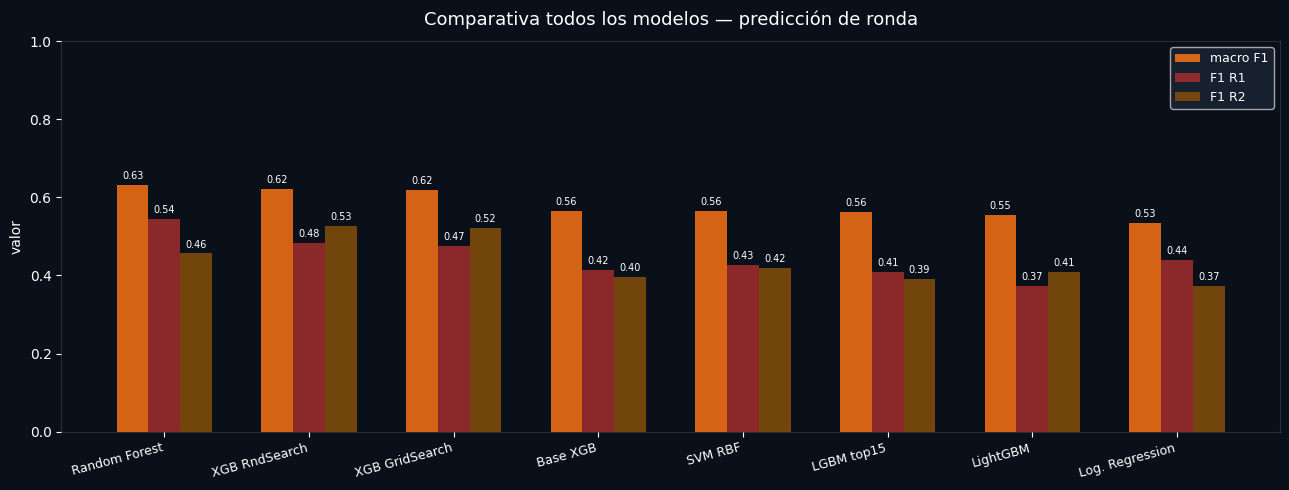

In [48]:
# gráfico comparativo final
fig, ax = plt.subplots(figsize=(13, 5))
fig.patch.set_facecolor('#0a1019')
ax.set_facecolor('#0a1019')

nombres = df_todos['modelo'].tolist()
x_pos = np.arange(len(nombres))
cols_m    = ['macro_f1', 'f1_R1', 'f1_R2']
colores_c = ['#f97316', '#A32D2D', '#854F0B']
etiq_c    = ['macro F1', 'F1 R1', 'F1 R2']
ancho_c   = 0.22

for i, (col, color, etiq) in enumerate(zip(cols_m, colores_c, etiq_c)):
    vals = df_todos[col].tolist()
    barras = ax.bar(x_pos + i * ancho_c, vals, ancho_c, label=etiq, color=color, alpha=0.85)
    for b in barras:
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.01,
                f'{b.get_height():.2f}', ha='center', va='bottom', fontsize=7, color='white')

ax.set_xticks(x_pos + ancho_c)
ax.set_xticklabels(nombres, color='white', fontsize=9, rotation=15, ha='right')
ax.set_ylim(0, 1.0)
ax.set_ylabel('valor', color='white')
ax.set_title('Comparativa todos los modelos — predicción de ronda', color='white', fontsize=13, pad=12)
ax.tick_params(colors='white')
ax.legend(facecolor='#1a2535', labelcolor='white', fontsize=9)
for spine in ax.spines.values():
    spine.set_edgecolor('#ffffff22')
plt.tight_layout()
plt.show()


In [49]:
os.makedirs('../../pkl/modelos', exist_ok=True)
os.makedirs('../../pkl/preprocesado', exist_ok=True)

joblib.dump(mejor_xgb,    '../../pkl/modelos/xgb_draft_randsearch.pkl')
joblib.dump(xgb_grid,     '../../pkl/modelos/xgb_draft_gridsearch.pkl')
joblib.dump(lgbm_model,   '../../pkl/modelos/lgbm_draft_balanceado.pkl')
joblib.dump(lgbm_top,     '../../pkl/modelos/lgbm_draft_top15.pkl')
joblib.dump(rf_model,     '../../pkl/modelos/rf_draft.pkl')
joblib.dump(svm_pipeline, '../../pkl/modelos/svm_draft.pkl')
joblib.dump(lr_pipeline,  '../../pkl/modelos/lr_draft.pkl')
joblib.dump(top15_vars,   '../../pkl/preprocesado/top15_vars_draft.pkl')
# el label encoder ya existe del primer modelo
# joblib.dump(le_target_draft, '../../pkl/preprocesado/le_target_draft.pkl')

print("Modelos guardados")


Modelos guardados


## Elección del modelo final — predicción de ronda

Tras comparar siete modelos (XGBoost base, XGBoost RandomizedSearch, XGBoost GridSearch, LightGBM, LightGBM top15, SVM RBF y Regresión Logística), el modelo elegido para predecir la ronda de draft es **Random Forest con pesos balanceados**.

### Resultados

| modelo | macro F1 | F1 ND | F1 R1 | F1 R2 |
|---|---|---|---|---|
| **Random Forest** | **0.6314** | **0.8939** | **0.5437** | **0.4565** |
| XGB RndSearch | 0.6223 | 0.8578 | 0.4828 | 0.5263 |
| XGB GridSearch | 0.6192 | 0.8606 | 0.4746 | 0.5225 |
| Base XGB | 0.5646 | 0.8826 | 0.4151 | 0.3962 |
| SVM RBF | 0.5642 | 0.8473 | 0.4259 | 0.4194 |
| LGBM top15 | 0.5631 | 0.8894 | 0.4082 | 0.3918 |
| LightGBM | 0.5546 | 0.8820 | 0.3736 | 0.4082 |
| Log. Regression | 0.5342 | 0.7888 | 0.4409 | 0.3729 |

### Por qué Random Forest

El macro F1 de 0.63 es el más alto de la comparativa, pero lo relevante para este proyecto es el rendimiento en R1 y R2 — las clases que determinan si un jugador entra en el draft y en qué ronda. Random Forest obtiene el mejor F1 en R1 (0.54) y el segundo mejor en R2 (0.46).

El resultado tiene una explicación intuitiva: Random Forest construye cientos de árboles independientes (bagging) y promedia sus predicciones. Con un dataset de tamaño moderado y clases desbalanceadas, esta estrategia generaliza mejor que el boosting secuencial de XGBoost o LightGBM, que tiende a sobreajustar las clases mayoritarias.

El pipeline de búsqueda de hiperparámetros (RandomizedSearch → GridSearch) mejoró el XGBoost base en +0.06 puntos de macro F1, lo que confirma que la optimización aporta valor. Sin embargo, incluso el XGB optimizado queda por debajo de Random Forest con sus parámetros fijos, lo que sugiere que el problema se adapta mejor al enfoque de bagging.

### Modelo guardado

`rf_draft.pkl` — Random Forest balanceado, entrenado sobre el subconjunto de variables seleccionado automáticamente por importancia.

In [51]:
# ── predicción individual — comprobación del modelo ──────────────────────────
# muestro jugadores del test con su ronda real para elegir por índice
X_test_original = ncaa.loc[X_test.index].copy()

print("Jugadores disponibles en test (índice | ronda):")
print(X_test_original['ronda'].to_string())

Jugadores disponibles en test (índice | ronda):
268     R2
99      R2
1886    ND
409     R1
542     R1
983     ND
1196    ND
462     R1
438     R2
242     R1
1736    ND
2026    ND
2088    ND
281     R1
964     ND
83      R2
1821    ND
387     R2
1703    ND
470     R1
1463    ND
277     R2
759     ND
1600    ND
479     R2
1905    ND
386     R1
1881    ND
1608    ND
344     R1
904     ND
1590    ND
613     R2
1973    ND
746     ND
685     ND
1056    ND
1551    ND
162     R2
640     ND
848     ND
1114    ND
1817    ND
169     R2
669     ND
1060    ND
873     ND
305     R1
1377    ND
127     R1
1986    ND
1471    ND
1677    ND
1199    ND
1489    ND
289     R1
275     R1
1635    ND
1132    ND
639     ND
1830    ND
337     R2
1735    ND
1426    ND
104     R2
1240    ND
1797    ND
1127    ND
1906    ND
1672    ND
1783    ND
1550    ND
2008    ND
1432    ND
924     ND
1433    ND
1669    ND
781     ND
293     R2
377     R1
29      R2
668     ND
1787    ND
282     R1
1812    ND
571     R1
1062  

In [52]:
# cambia idx por cualquier índice de los de arriba
idx = 242  # <-- modifica aquí

X_jugador   = X_test.loc[[idx]]
ronda_pred  = le_target_draft.inverse_transform(rf_model.predict(X_jugador))[0]
ronda_real  = ncaa.loc[idx, 'ronda']
probas      = rf_model.predict_proba(X_jugador)[0]

print(f"Índice:         {idx}")
print(f"Ronda real:     {ronda_real}")
print(f"Ronda predicha: {ronda_pred}")
print(f"\nProbabilidades:")
for clase, prob in zip(le_target_draft.classes_, probas):
    barra = '█' * int(prob * 30)
    print(f"  {clase}  {barra} {prob:.2%}")

Índice:         242
Ronda real:     R1
Ronda predicha: R1

Probabilidades:
  ND  █████ 17.37%
  R1  █████████████████ 59.57%
  R2  ██████ 23.06%


In [53]:
# cambia idx por cualquier índice de los de arriba
idx = 1463  # <-- modifica aquí

X_jugador   = X_test.loc[[idx]]
ronda_pred  = le_target_draft.inverse_transform(rf_model.predict(X_jugador))[0]
ronda_real  = ncaa.loc[idx, 'ronda']
probas      = rf_model.predict_proba(X_jugador)[0]

print(f"Índice:         {idx}")
print(f"Ronda real:     {ronda_real}")
print(f"Ronda predicha: {ronda_pred}")
print(f"\nProbabilidades:")
for clase, prob in zip(le_target_draft.classes_, probas):
    barra = '█' * int(prob * 30)
    print(f"  {clase}  {barra} {prob:.2%}")

Índice:         1463
Ronda real:     ND
Ronda predicha: ND

Probabilidades:
  ND  ██████████████████ 60.08%
  R1  █████ 19.37%
  R2  ██████ 20.55%


In [54]:
# cambia idx por cualquier índice de los de arriba
idx = 277  # <-- modifica aquí

X_jugador   = X_test.loc[[idx]]
ronda_pred  = le_target_draft.inverse_transform(rf_model.predict(X_jugador))[0]
ronda_real  = ncaa.loc[idx, 'ronda']
probas      = rf_model.predict_proba(X_jugador)[0]

print(f"Índice:         {idx}")
print(f"Ronda real:     {ronda_real}")
print(f"Ronda predicha: {ronda_pred}")
print(f"\nProbabilidades:")
for clase, prob in zip(le_target_draft.classes_, probas):
    barra = '█' * int(prob * 30)
    print(f"  {clase}  {barra} {prob:.2%}")

Índice:         277
Ronda real:     R2
Ronda predicha: R2

Probabilidades:
  ND  ██████ 22.44%
  R1  ███████████ 37.48%
  R2  ████████████ 40.08%


Acierta, pero con solo un 40% — prácticamente un empate técnico con R1 (37%). Eso es exactamente lo que el F1 de 0.46 en R2 ya anticipaba: el modelo distingue R2 de ND razonablemente, pero le cuesta separar R2 de R1.
Tiene mucho sentido conceptualmente — la frontera entre el pick 30 y el pick 31 es casi arbitraria en la realidad. Un jugador de segunda ronda alta y uno de primera ronda baja tienen perfiles estadísticos muy similares, y lo que los separa suele ser el día del draft, no sus números en NCAA.
Para el proyecto esto es en realidad un argumento narrativo potente: el modelo captura bien quién entra en el draft (ND vs drafteado), y en la frontera R1/R2 refleja fielmente la incertidumbre real que existe en esa zona.